## <b>Data Loading & Pre-Processing</b>

In [1]:
from torchvision import datasets, transforms

#### <b>Defining Transformations</b>

In [2]:
# Defining transformation for EDA (Exploratory Data Analysis)

eda_transformations = transforms.Compose([
    # Resizing the images to a standard size (e.g., 224x224) for visualization
    transforms.Resize((224, 224)),
    # Converting the images to PyTorch tensors for further processing
    transforms.ToTensor()
])

In [3]:
# Defining transformations for model training

train_transformations = transforms.Compose([
    # Resizing the images to a standard size (e.g., 224x224) for model input
    transforms.Resize((224, 224)),
    # Applying ColorJitter for data augmentation to improve model robustness
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    # Converting the images to PyTorch tensors for model training
    transforms.ToTensor(),
    # Normalizing the images using mean and standard deviation values commonly used for pre-trained models
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
# Defining transformations for validation, testing and inference

other_transformations = transforms.Compose([
    # Resizing the images to a standard size (e.g., 224x224) for model input
    transforms.Resize((224, 224)),
    # Converting the images to PyTorch tensors for model evaluation and inference
    transforms.ToTensor(),
    # Normalizing the images using mean and standard deviation values commonly used for pre-trained models
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#### <b>Importing Datasets and Applying Transformations</b>

In [5]:
# Loading the dataset and applying the transformations defined.
# The ImageFolder class is used to load images from a directory structure where each subdirectory represents a class label.
eda_dataset = datasets.ImageFolder('dataset_split/train', transform=eda_transformations)
train_dataset = datasets.ImageFolder('dataset_split/train', transform=train_transformations)
val_dataset = datasets.ImageFolder('dataset_split/val', transform=other_transformations)
test_dataset = datasets.ImageFolder('dataset_split/test', transform=other_transformations)
train_eval_dataset = datasets.ImageFolder('dataset_split/train', transform=other_transformations)

print(train_dataset.classes)
print(val_dataset.classes)
print(test_dataset.classes)

['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


## <b>Exploratory Data Analysis</b>

In [6]:
import os
import matplotlib.pyplot as plt

#### <b>Class Distribution</b>

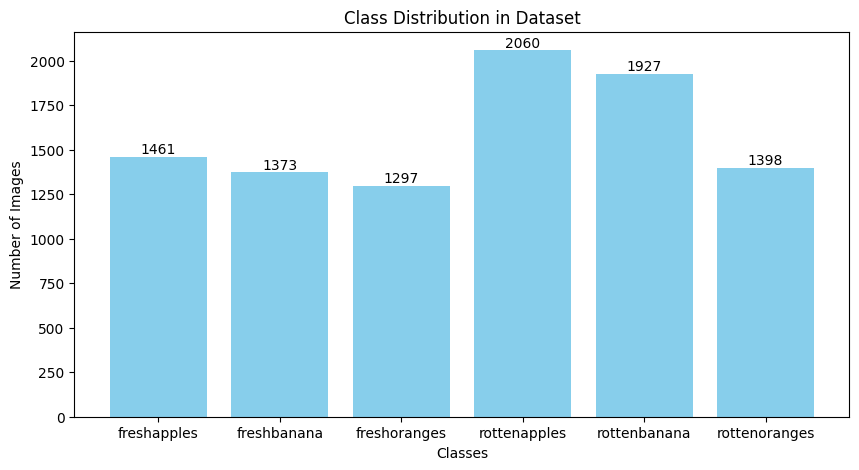

In [7]:
# Extracting the classes from the dataset.
class_names = eda_dataset.classes

# Counting the number of records in each Class Distribution
class_counts = {cls: len(os.listdir(os.path.join('dataset_split/train', cls))) for cls in class_names}

plt.figure(figsize=(10, 5))
bar = plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.bar_label(bar)
plt.title('Class Distribution in Dataset')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.xticks()
plt.show()

#### <b>Visualizing Sample Images</b>

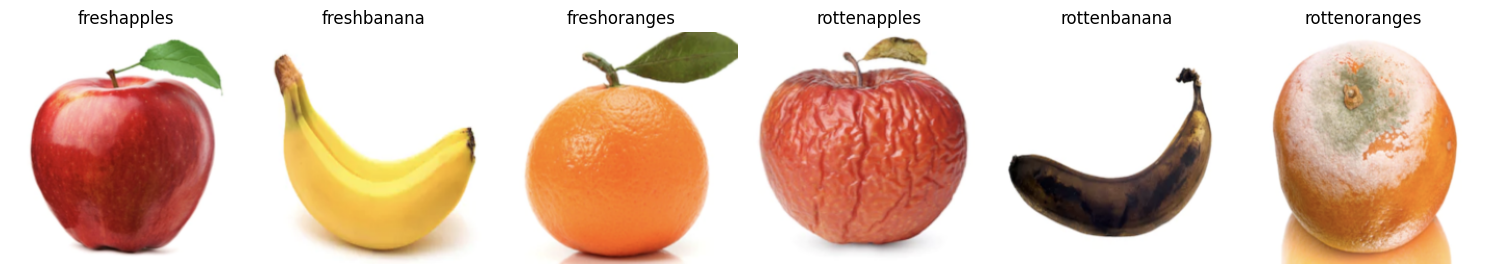

In [8]:
# Defining the figure and axis grid based on the number of classes
fig, axes = plt.subplots(1, len(class_names), figsize=(15, 5))

# Iterating through each class to find and plot a sample
for i, cls in enumerate(class_names):
    # Finding the index of the first occurrence of this class
    image_index = eda_dataset.targets.index(i)
    image, _ = eda_dataset[image_index]
    
    # changing the image from C, H, W to H, W, C for plotting
    image = image.permute(1,2,0)

    # Plot the image on the specific axis
    axes[i].imshow(image)
    # Set class name as title
    axes[i].set_title(cls)
    # Hide axis ticks
    axes[i].axis('off')

# Adjusting layout to prevent overlapping
plt.tight_layout()
plt.show()

## <b>Model Training</b>

In [9]:
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler

In [10]:
# Setting device to use for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### <b>Creating Functions for Dataloaders to load data with batch_sizes</b>

In [11]:
# Creating DataLoaders for training, validation, and testing datasets with appropriate sampling to handle class imbalance.
def create_dataloaders(batch_size=32):
    # Calculating class weights for handling class imbalance in the training dataset
    class_names_list = [class_counts[cls] for cls in class_names]
    class_weights = [1.0 / count for count in class_names_list]

    # Creating a list of sample weights for each image in the training dataset based on its class label
    sample_weights = [
        class_weights[label]
        for label in train_dataset.targets
    ]

    # Creating a WeightedRandomSampler to sample the training data according to the calculated sample weights
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        # Setting replacement to True allows for sampling with replacement
        replacement=True
    )

    # Creating DataLoaders for training, validation, and testing datasets
    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
    train_eval_loader = DataLoader(train_eval_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, train_eval_loader, val_loader, test_loader

# Calling the function to create DataLoaders for training, validation, and testing datasets
train_loader, train_eval_loader, val_loader, test_loader = create_dataloaders(batch_size=32)

#### <b>Defining Function for Traning model</b>

In [12]:
import torch.nn as nn
import torch.optim as optim

In [13]:
# Defining Unified Model Traning logic
def train_model(model, criterion, optimizer, train_loader, val_loader, device, epochs=0, save_path='model.pth'):
    model.to(device)
    # Initializing a history dictionary to store training and validation loss and accuracy for each epoch.
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    best_val_acc = 0.0

    # Looping through each epoch to train the model and evaluate on the validation set
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        corrects = 0
        
        # Iterating through the training DataLoader to get batches of inputs and labels for training
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            
            # Backpropagation
            loss.backward()
            # Updating Weights
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            corrects += torch.sum(preds == labels.data)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = corrects.double() / len(train_loader.dataset)
        
        # Evaluating the model on the validation set after each epoch
        model.eval()
        val_running_loss = 0.0
        val_corrects = 0
        
        # Disabling gradient calculation for validation to save memory and computation
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                
                val_running_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
        
        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = val_corrects.double() / len(val_loader.dataset)
        
        # Saving the model if the validation accuracy has improved
        if val_acc > best_val_acc:
            best_val_acc = val_acc

            if save_path is not None:
                torch.save(model.state_dict(), save_path)
        
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc.item())
        
        # Printing the training and validation loss and accuracy for the current epoch
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        
    return history

#### <b>Model 1: Baseline CNN from Scratch</b>

##### Defining Baseline CNN Model

In [14]:
# Baseline CNN (From Scratch)
class BaselineCNN(nn.Module):
    # Initializing the BaselineCNN class which inherits from nn.Module to define a simple CNN architecture for image classification.
    def __init__(self):
        super().__init__()
        # Defining a simple CNN architecture with two convolutional layers followed by a fully connected layer for classification.
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        # Defining a fully connected layer that takes the output from the convolutional layers and produces 6 output classes for classification.
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 56 * 56, 6)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

##### Training Baseline CNN Model

In [15]:
print("Training Baseline CNN Model")
model_baseline = BaselineCNN()
# Training the Baseline CNN model using the defined training function with CrossEntropyLoss and Adam optimizer
stats_baseline = train_model(
    model_baseline, 
    nn.CrossEntropyLoss(), 
    optim.Adam(model_baseline.parameters(), lr=0.0005),
    # Passing the training and validation DataLoaders, device, number of epochs, and path to save the best model based on validation loss.
    train_loader, val_loader, device, epochs=6, save_path='baseline_best.pth')

Training Baseline CNN Model
Epoch 1/6 | Train Loss: 0.5971 | Train Acc: 0.7992 | Val Loss: 0.3439 | Val Acc: 0.8867
Epoch 2/6 | Train Loss: 0.2451 | Train Acc: 0.9146 | Val Loss: 0.3110 | Val Acc: 0.9043
Epoch 3/6 | Train Loss: 0.1679 | Train Acc: 0.9416 | Val Loss: 0.2860 | Val Acc: 0.9141
Epoch 4/6 | Train Loss: 0.1154 | Train Acc: 0.9635 | Val Loss: 0.2758 | Val Acc: 0.9146
Epoch 5/6 | Train Loss: 0.0971 | Train Acc: 0.9673 | Val Loss: 0.2413 | Val Acc: 0.9328
Epoch 6/6 | Train Loss: 0.0752 | Train Acc: 0.9761 | Val Loss: 0.2619 | Val Acc: 0.9239


#### <b>Model 2: Improvised/Tuned CNN</b>

##### Defining Improved CNN Model

In [16]:
class ImprovedCNN(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        # Correct adaptive pooling layer
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 6)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

##### Hyperparameter tuning & Improved Model Training

In [22]:
learning_rates = [0.0001, 0.0005]
dropout_rates = [0.3]

best_val_acc = 0.0
best_learning_rate = None
best_dropout_rate = None
stats_improved = None
tuning_results = {}

for lr in learning_rates:
    for dropout_rate in dropout_rates:

        print(f"\nTraining Improved CNN Model | LR: {lr} | Dropout: {dropout_rate}")

        improved_model_temp = ImprovedCNN(dropout_rate=dropout_rate)

        optimizer = optim.Adam(
            improved_model_temp.parameters(),
            lr=lr,
            weight_decay=1e-4
        )

        temp_save_path = "temp_improved_best.pth"

        stats_temp = train_model(
            improved_model_temp,
            nn.CrossEntropyLoss(),
            optimizer,
            train_loader,
            val_loader,
            device,
            epochs=10,
            save_path=temp_save_path
        )

        current_best_val_acc = max(stats_temp['val_acc'])

        tuning_results[(lr, dropout_rate)] = current_best_val_acc

        print(
            f"Best Validation Accuracy for LR={lr}, Dropout={dropout_rate}: "
            f"{current_best_val_acc:.4f}"
        )

        if current_best_val_acc > best_val_acc:
            best_val_acc = current_best_val_acc
            best_learning_rate = lr
            best_dropout_rate = dropout_rate
            stats_improved = stats_temp

            best_weights = torch.load(temp_save_path, map_location=device)
            torch.save(best_weights, "improved_best.pth")


print("\n" + "=" * 50)
print("Best Improved CNN Hyperparameters")
print("=" * 50)
print(f"Best Learning Rate: {best_learning_rate}")
print(f"Best Dropout Rate: {best_dropout_rate}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

print("\nAll Tuning Results:")
for params, acc in tuning_results.items():
    lr, dropout_rate = params
    print(f"LR: {lr}, Dropout: {dropout_rate} -> Best Val Acc: {acc:.4f}")


Training Improved CNN Model | LR: 0.0001 | Dropout: 0.3
Epoch 1/10 | Train Loss: 1.3333 | Train Acc: 0.5903 | Val Loss: 0.9495 | Val Acc: 0.7601
Epoch 2/10 | Train Loss: 0.8885 | Train Acc: 0.7397 | Val Loss: 0.6662 | Val Acc: 0.8086
Epoch 3/10 | Train Loss: 0.7036 | Train Acc: 0.7795 | Val Loss: 0.5579 | Val Acc: 0.8145
Epoch 4/10 | Train Loss: 0.6259 | Train Acc: 0.7988 | Val Loss: 0.4788 | Val Acc: 0.8557
Epoch 5/10 | Train Loss: 0.5676 | Train Acc: 0.8149 | Val Loss: 0.4392 | Val Acc: 0.8503
Epoch 6/10 | Train Loss: 0.5104 | Train Acc: 0.8283 | Val Loss: 0.4565 | Val Acc: 0.8356
Epoch 7/10 | Train Loss: 0.4798 | Train Acc: 0.8409 | Val Loss: 0.3740 | Val Acc: 0.8808
Epoch 8/10 | Train Loss: 0.4564 | Train Acc: 0.8467 | Val Loss: 0.4500 | Val Acc: 0.8288
Epoch 9/10 | Train Loss: 0.4465 | Train Acc: 0.8499 | Val Loss: 0.3247 | Val Acc: 0.8950
Epoch 10/10 | Train Loss: 0.4112 | Train Acc: 0.8599 | Val Loss: 0.3179 | Val Acc: 0.8852
Best Validation Accuracy for LR=0.0001, Dropout=0.3:

#### <b>Fine-Tuned/Pre-Trained Model</b>

In [23]:
import torchvision.models as models

In [25]:
print("Training Pre-trained CNN Model")
# Initializing the ResNet18 model for transfer learning and modifying the final fully connected layer to output 6 classes for our specific classification task.
model_transfer = models.resnet18(weights='IMAGENET1K_V1')
model_transfer.fc = nn.Linear(model_transfer.fc.in_features, 6)

# Training the Transfer Learning model using the defined training function with CrossEntropyLoss and Adam optimizer
stats_transfer = train_model(
    model_transfer,
    nn.CrossEntropyLoss(),
    optim.Adam(model_transfer.parameters(), lr=0.0001),
    train_loader,
    val_loader,
    device,
    epochs=6,
    save_path='transfer_best.pth'
)

Training Pre-trained CNN Model
Epoch 1/6 | Train Loss: 0.0987 | Train Acc: 0.9707 | Val Loss: 0.0182 | Val Acc: 0.9946
Epoch 2/6 | Train Loss: 0.0210 | Train Acc: 0.9951 | Val Loss: 0.0061 | Val Acc: 0.9990
Epoch 3/6 | Train Loss: 0.0098 | Train Acc: 0.9979 | Val Loss: 0.0296 | Val Acc: 0.9897
Epoch 4/6 | Train Loss: 0.0091 | Train Acc: 0.9980 | Val Loss: 0.0067 | Val Acc: 0.9980
Epoch 5/6 | Train Loss: 0.0094 | Train Acc: 0.9971 | Val Loss: 0.0081 | Val Acc: 0.9980
Epoch 6/6 | Train Loss: 0.0043 | Train Acc: 0.9989 | Val Loss: 0.0028 | Val Acc: 0.9995


## <b>Model's Performance Evaluation</b>

In [26]:
from sklearn.metrics import classification_report, confusion_matrix

#### <b>Defining Evaluation Function</b>

In [27]:
def evaluate(model, loader, title):
    y_true, y_pred = [], []

    # Setting the model to evaluation mode and disabling gradient calculation to evaluate the model on the given DataLoader
    model.eval()
    with torch.no_grad():
        for x, y in loader:
            pred = model(x.to(device)).argmax(1)
            y_true += y.numpy().tolist()
            y_pred += pred.cpu().numpy().tolist()

    # Classification Report
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    table_data = [[label, f"{m['precision']:.4f}", f"{m['recall']:.4f}", f"{m['f1-score']:.4f}", f"{int(m['support'])}"] 
                  if isinstance(m, dict) else [label, "", "", f"{m:.4f}", ""] 
                  for label, m in report.items()]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    axes[0].axis('off')
    the_table = axes[0].table(cellText=table_data, colLabels=["", "precision", "recall", "f1-score", "support"], loc='center')
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(11)

    for (row, col), cell in the_table.get_celld().items():
        cell.set_height(0.08)
        cell.set_text_props(verticalalignment='center')
        if row == 0:
            cell.set_text_props(weight='bold')
            
    axes[0].set_title(f"{title} - Classification Report", fontsize=14)

    # ---- Confusion Matrix ----
    cm = confusion_matrix(y_true, y_pred)

    axes[1].imshow(cm, cmap=plt.cm.Purples)
    plt.colorbar(axes[1].images[0], ax=axes[1])
    axes[1].set_xticks(range(len(class_names)))
    axes[1].set_xticklabels(class_names, rotation=45, fontsize=10)
    axes[1].set_yticks(range(len(class_names)))
    axes[1].set_yticklabels(class_names, fontsize=10)

    for i in range(len(cm)):
        for j in range(len(cm)):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            axes[1].text(j, i, cm[i, j], ha='center', va='center', fontsize=10, color=color)

    axes[1].set_title(title, fontsize=14)
    axes[1].set_xlabel("Predicted", fontsize=12)
    axes[1].set_ylabel("Actual", fontsize=12)
    plt.tight_layout()
    plt.show()

In [28]:
# Reload best saved weights before final evaluation

# Best Baseline CNN
model_baseline = BaselineCNN()
model_baseline.load_state_dict(torch.load("baseline_best.pth", map_location=device))
model_baseline.to(device)
model_baseline.eval()

# Best Improved CNN
model_improved = ImprovedCNN(dropout_rate=best_dropout_rate)
model_improved.load_state_dict(torch.load("improved_best.pth", map_location=device))
model_improved.to(device)
model_improved.eval()

# Best ResNet18 Transfer Learning Model
model_transfer = models.resnet18(weights=None)
model_transfer.fc = nn.Linear(model_transfer.fc.in_features, 6)
model_transfer.load_state_dict(torch.load("transfer_best.pth", map_location=device))
model_transfer.to(device)
model_transfer.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#### <b>Evaluation of Baseline CNN Model</b>


Model 1: Baseline CNN


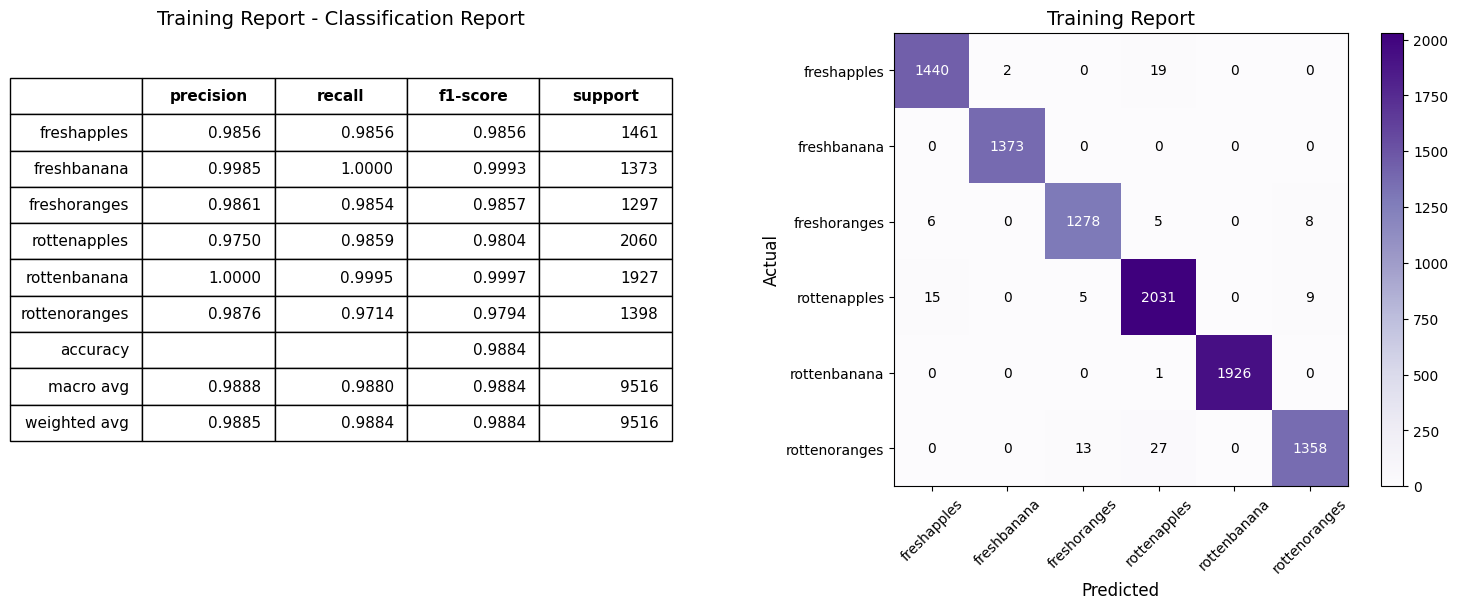

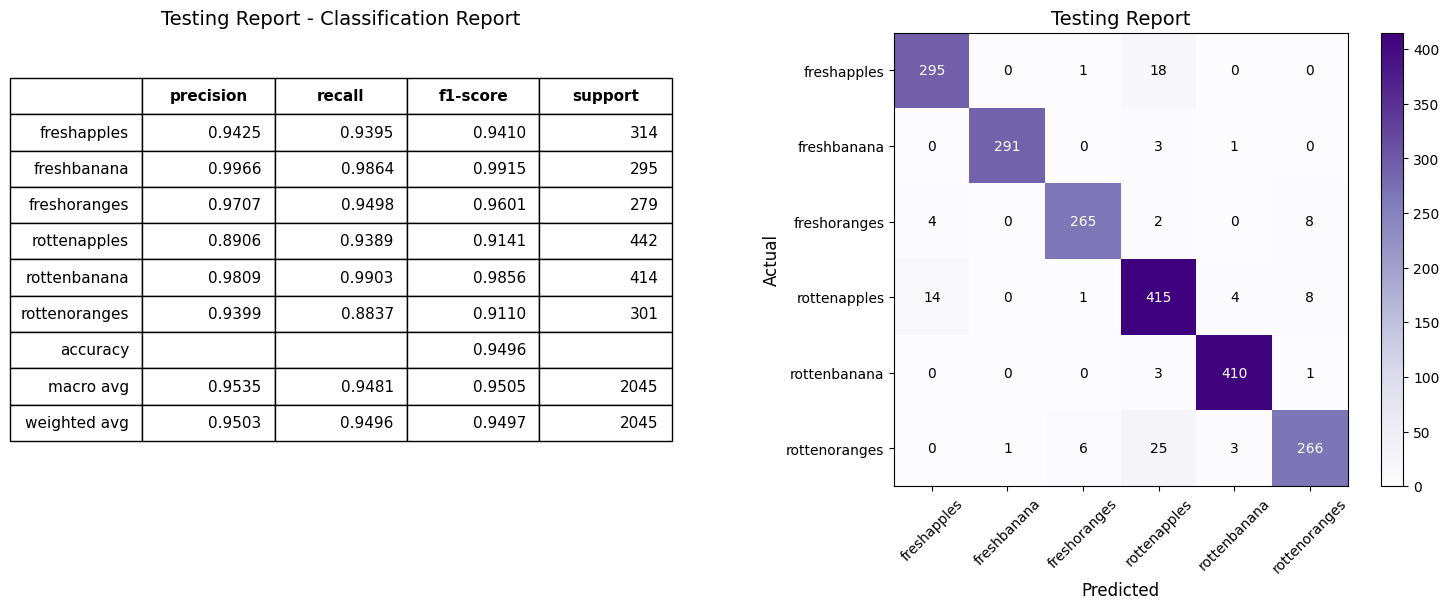

In [29]:
print("\n" + "="*50)
print("Model 1: Baseline CNN")
print("="*50)
evaluate(model_baseline, train_eval_loader, "Training Report")
evaluate(model_baseline, test_loader, "Testing Report")

#### <b>Evaluation of Improved CNN Model</b>


Model 2: Improved CNN


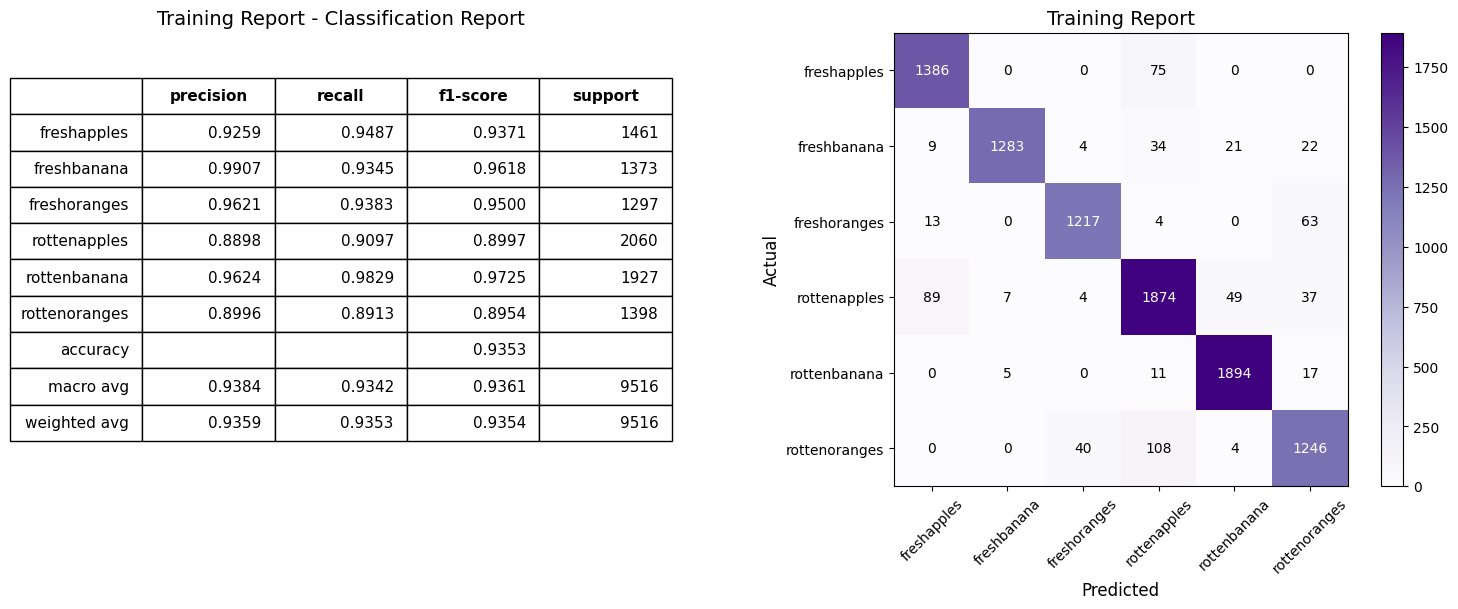

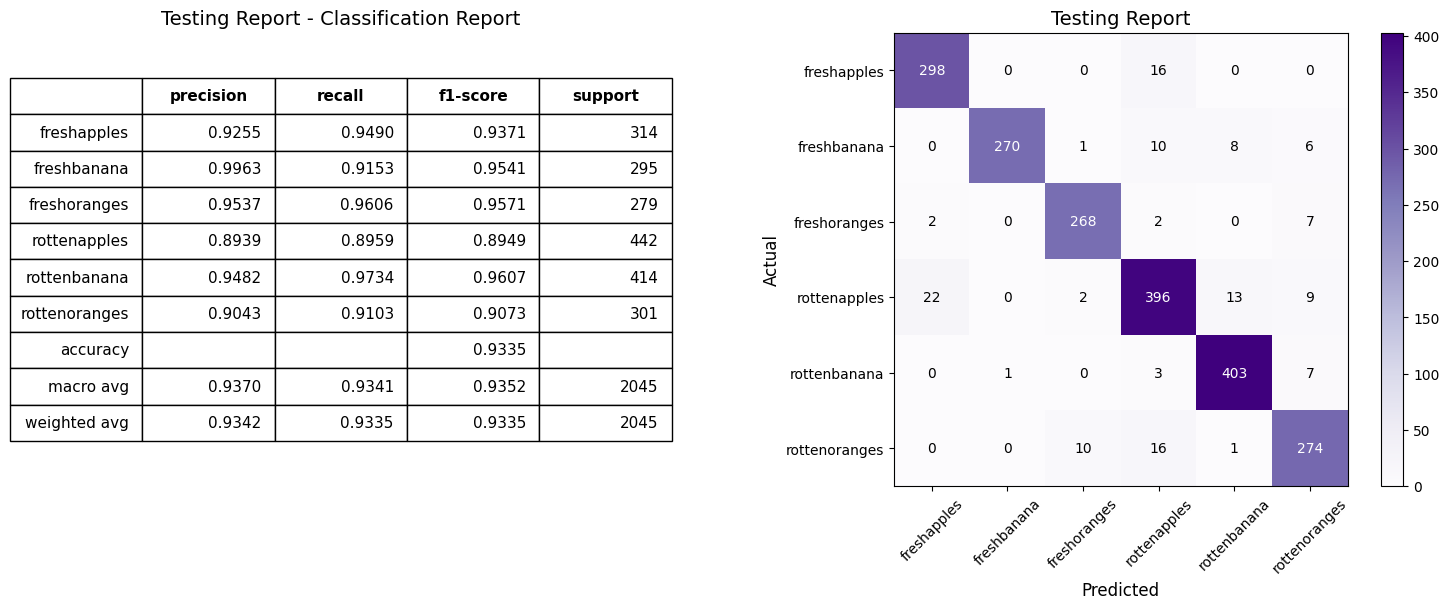

In [30]:
print("\n" + "="*50)
print("Model 2: Improved CNN")
print("="*50)
evaluate(model_improved, train_eval_loader, "Training Report")
evaluate(model_improved, test_loader, "Testing Report")

#### <b>Evaluation of Transfer Learning Model</b>


Model 3: Transfer Learning (ResNet18)


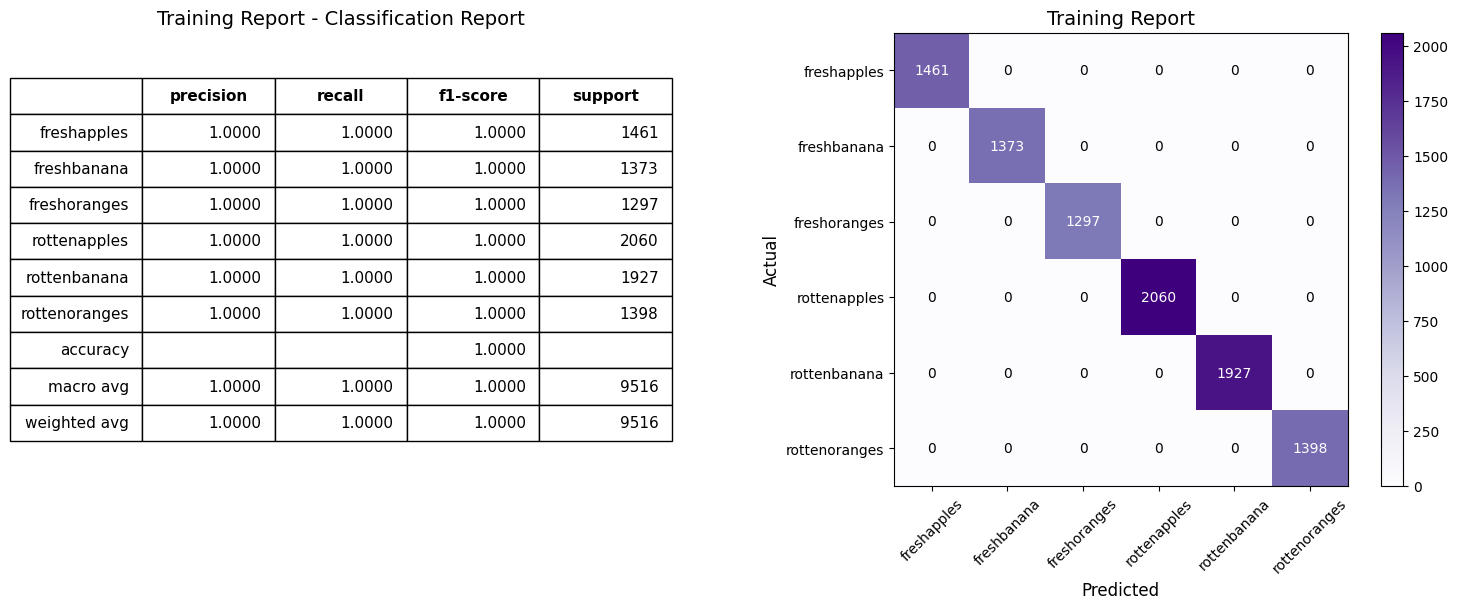

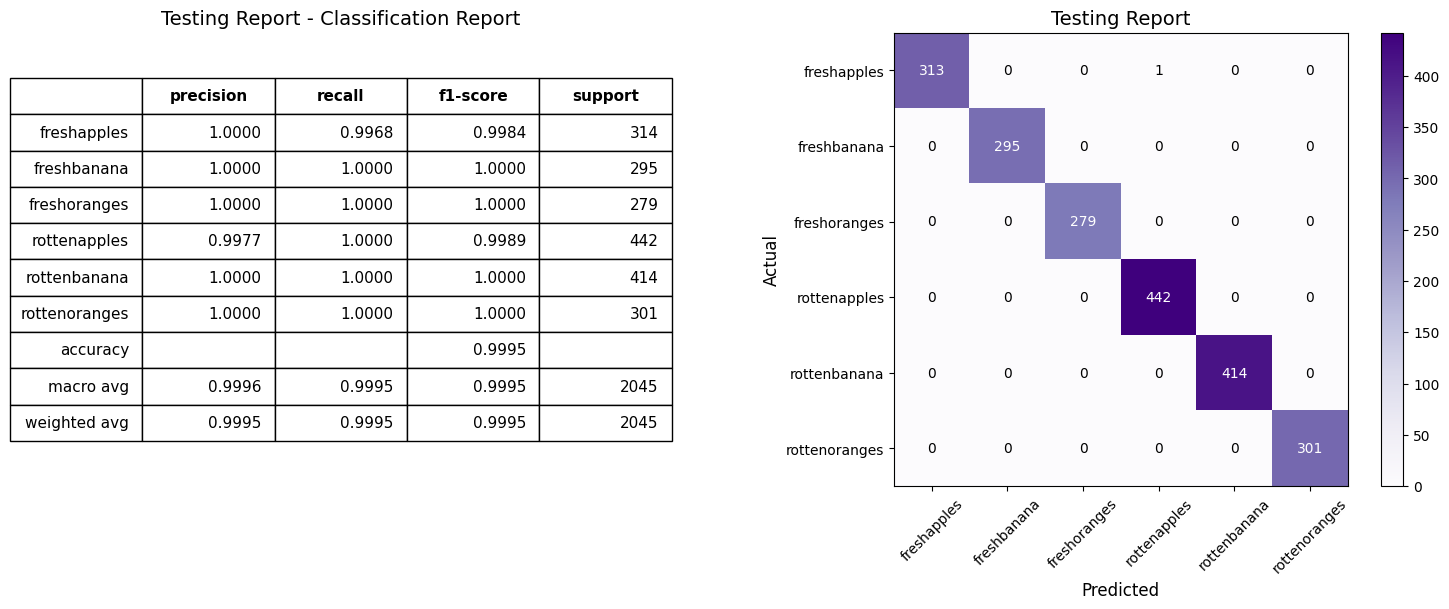

In [31]:
print("\n" + "="*50)
print("Model 3: Transfer Learning (ResNet18)")
print("="*50)
evaluate(model_transfer, train_eval_loader, "Training Report")
evaluate(model_transfer, test_loader, "Testing Report")

## <b>Model Comparison</b>

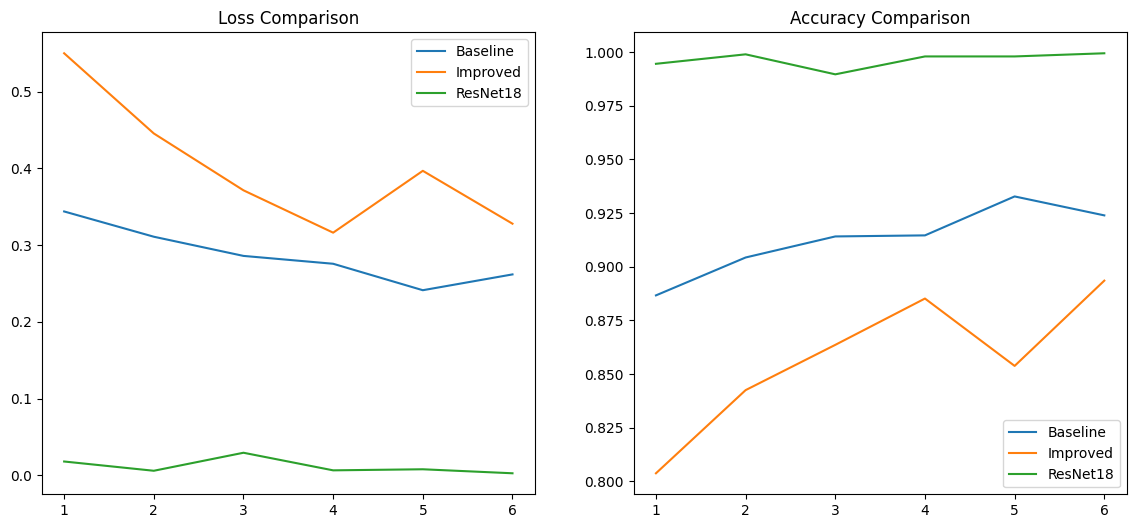

In [34]:
min_epochs = min(len(stats_baseline['val_loss']),
                 len(stats_improved['val_loss']),
                 len(stats_transfer['val_loss']))

epochs = range(1, min_epochs + 1)

plt.figure(figsize=(14,6))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, stats_baseline['val_loss'][:min_epochs], label='Baseline')
plt.plot(epochs, stats_improved['val_loss'][:min_epochs], label='Improved')
plt.plot(epochs, stats_transfer['val_loss'][:min_epochs], label='ResNet18')
plt.title('Loss Comparison')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, stats_baseline['val_acc'][:min_epochs], label='Baseline')
plt.plot(epochs, stats_improved['val_acc'][:min_epochs], label='Improved')
plt.plot(epochs, stats_transfer['val_acc'][:min_epochs], label='ResNet18')
plt.title('Accuracy Comparison')
plt.legend()

plt.show()

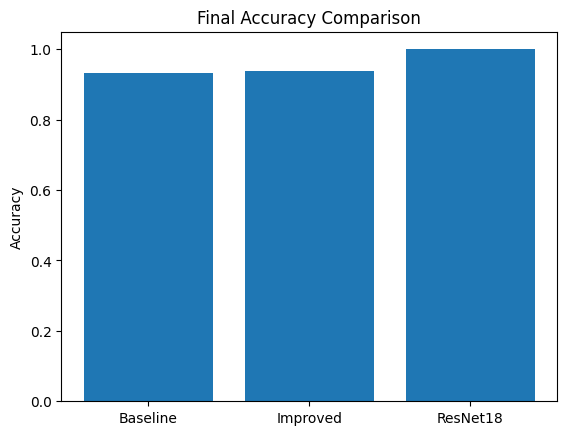

In [33]:
models = ['Baseline', 'Improved', 'ResNet18']
final_acc = [
    max(stats_baseline['val_acc']),
    max(stats_improved['val_acc']),
    max(stats_transfer['val_acc'])
]

plt.bar(models, final_acc)
plt.title("Final Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()